# SwiftDrop Nigeria — Product Analytics Case Study
## Solving 5 Real Business Problems with Data

**Company:** SwiftDrop Nigeria (fictional logistics platform)  
**Period:** October 2023 – September 2024  
**Dataset:** 25,000 customers | 196,191 orders | 143,661 funnel events  

---

### Business Problems We Are Solving
1. Why is revenue declining despite growing users?
2. Which customers are most likely to churn next month?
3. Where is the product losing customers in the journey?
4. Which marketing channel brings the best customers?
5. How do we increase repeat orders?

---

## Setup — Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.facecolor': '#fafaf8',
    'axes.facecolor':   '#fafaf8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid':        True,
    'grid.color':       '#e8e4dc',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'axes.labelcolor':  '#5c5848',
    'xtick.color':      '#9c9480',
    'ytick.color':      '#9c9480',
    'text.color':       '#1c1a14',
})

ORANGE = '#e8621a'
GREEN  = '#1a7a4a'
BLUE   = '#1a4a8a'
RED    = '#c02020'
AMBER  = '#c07010'
PURPLE = '#6030a0'
GRAY   = '#9c9480'

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
users  = pd.read_csv('swiftdrop_users.csv')
orders = pd.read_csv('swiftdrop_orders.csv')
funnel = pd.read_csv('swiftdrop_funnel.csv')

# Parse dates
users['signup_date']      = pd.to_datetime(users['signup_date'])
users['last_active_date'] = pd.to_datetime(users['last_active_date'])
orders['order_date']      = pd.to_datetime(orders['order_date'])
funnel['event_date']      = pd.to_datetime(funnel['event_date'])

print(f"Users loaded:          {len(users):,}")
print(f"Orders loaded:         {len(orders):,}")
print(f"Funnel events loaded:  {len(funnel):,}")
print(f"\nDate range: {orders['order_date'].min().strftime('%b %Y')} to {orders['order_date'].max().strftime('%b %Y')}")

Users loaded:          25,000
Orders loaded:         196,191
Funnel events loaded:  143,661

Date range: Oct 2023 to Sep 2024


---
## Section 1 — Company Overview

Before diving into the problems, let us understand the headline numbers.
These are the metrics we will show on the first slide of any executive presentation.

In [3]:
# ── KEY METRICS OVERVIEW ──────────────────────────────────────────────
succ = orders[orders['status'] == 'Delivered']

total_users     = len(users)
activated       = users['activated'].sum()
activation_rate = users['activated'].mean() * 100
churned         = users['is_churned'].sum()
churn_rate      = users['is_churned'].mean() * 100
total_revenue   = succ['final_price'].sum()
total_orders    = len(orders)
delivered       = len(succ)
delivery_rate   = len(succ) / len(orders) * 100
avg_order_val   = succ['final_price'].mean()

print("=" * 50)
print("  SWIFTDROP NIGERIA — KEY METRICS OVERVIEW")
print("=" * 50)
print(f"  Total Customers:      {total_users:,}")
print(f"  Activated:            {activated:,} ({activation_rate:.1f}%)")
print(f"  Churned:              {churned:,} ({churn_rate:.1f}%)")
print(f"  Total Orders:         {total_orders:,}")
print(f"  Delivered:            {delivered:,} ({delivery_rate:.1f}%)")
print(f"  Total Revenue:        ₦{total_revenue:,.0f}")
print(f"  Avg Order Value:      ₦{avg_order_val:,.0f}")
print("=" * 50)

  SWIFTDROP NIGERIA — KEY METRICS OVERVIEW
  Total Customers:      25,000
  Activated:            14,312 (57.2%)
  Churned:              21,322 (85.3%)
  Total Orders:         196,191
  Delivered:            180,299 (91.9%)
  Total Revenue:        ₦828,791,980
  Avg Order Value:      ₦4,597


---
## Problem 1 — Why Is Revenue Declining Despite Growing Users?

**The question from the CEO:** Our user count keeps growing month-on-month,
but revenue started declining from July 2024. What is happening?

**Our hypothesis:** The discount policy changes are the root cause — not user quality.

In [4]:
# ── MONTHLY REVENUE TREND ─────────────────────────────────────────────
monthly = succ.groupby('order_month').agg(
    revenue      = ('final_price', 'sum'),
    orders       = ('order_id', 'count'),
    active_users = ('user_id', 'nunique'),
    avg_discount = ('discount_pct', 'mean')
).reset_index()

monthly['rev_per_user'] = (monthly['revenue'] / monthly['active_users']).round(0)
monthly['revenue_M']    = (monthly['revenue'] / 1e6).round(2)

print("Monthly Revenue Summary:")
print(monthly[['order_month','revenue_M','active_users','avg_discount','rev_per_user']].to_string(index=False))

Monthly Revenue Summary:
order_month  revenue_M  active_users  avg_discount  rev_per_user
    2023-10      20.74          1131     20.000000       18339.0
    2023-11      44.56          2205     20.000000       20208.0
    2023-12      57.58          2693     20.000000       21383.0
    2024-01      65.66          2897     20.000000       22664.0
    2024-02      62.44          2964     20.000000       21065.0
    2024-03      71.70          3227     20.000000       22217.0
    2024-04      86.75          3218      0.276617       26959.0
    2024-05      96.75          3421      0.295962       28280.0
    2024-06      94.30          3461      0.248464       27245.0
    2024-07      89.14          3598     10.085539       24774.0
    2024-08      95.16          3661     10.086254       25992.0
    2024-09      44.03          2177     10.082108       20224.0


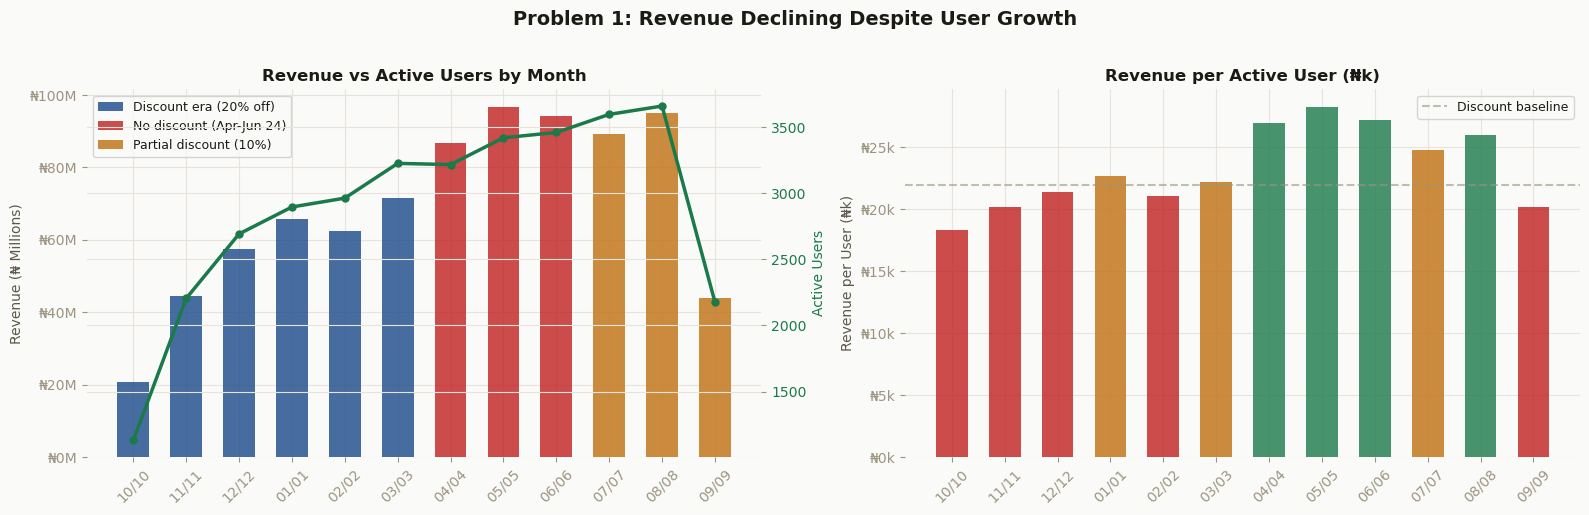

Chart saved as p1_revenue_trend.png


In [5]:
# ── VISUALISE REVENUE TREND ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Problem 1: Revenue Declining Despite User Growth', 
             fontsize=14, fontweight='bold', color='#1c1a14', y=1.02)

months_short = [m[-2:] + '/' + m[:7][-2:] for m in monthly['order_month']]

# Chart 1: Revenue bars with user line
ax1 = axes[0]
bar_colors = []
for i, m in enumerate(monthly['order_month']):
    if '2024-04' <= m <= '2024-06':
        bar_colors.append(RED)        # Discount removed — problem phase
    elif m >= '2024-07':
        bar_colors.append(AMBER)      # Partial recovery
    else:
        bar_colors.append(BLUE)       # Discount era

bars = ax1.bar(months_short, monthly['revenue_M'], color=bar_colors, 
               alpha=0.8, width=0.6, zorder=2)
ax2 = ax1.twinx()
ax2.plot(months_short, monthly['active_users'], color=GREEN, 
         linewidth=2.5, marker='o', markersize=5, zorder=3, label='Active Users')
ax2.set_ylabel('Active Users', color=GREEN, fontsize=10)
ax2.tick_params(axis='y', labelcolor=GREEN)
ax2.spines['right'].set_visible(False)
ax1.set_title('Revenue vs Active Users by Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue (₦ Millions)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₦{x:.0f}M'))

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BLUE, alpha=0.8, label='Discount era (20% off)'),
    Patch(facecolor=RED,  alpha=0.8, label='No discount (Apr-Jun 24)'),
    Patch(facecolor=AMBER,alpha=0.8, label='Partial discount (10%)'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)

# Chart 2: Revenue per user
ax3 = axes[1]
colors2 = [RED if v < 22000 else GREEN if v > 25000 else AMBER 
           for v in monthly['rev_per_user']]
ax3.bar(months_short, monthly['rev_per_user']/1000, color=colors2, 
        alpha=0.8, width=0.6, zorder=2)
ax3.set_title('Revenue per Active User (₦k)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Revenue per User (₦k)', fontsize=10)
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₦{x:.0f}k'))
ax3.axhline(y=22, color=GRAY, linestyle='--', alpha=0.6, label='Discount baseline')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('p1_revenue_trend.png', dpi=150, bbox_inches='tight', 
            facecolor='#fafaf8')
plt.show()
print("Chart saved as p1_revenue_trend.png")

In [6]:
# ── ROOT CAUSE ANALYSIS: DISCOUNT IMPACT ─────────────────────────────
disc_analysis = orders.groupby('discount_pct').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('final_price', 'sum'),
    avg_value     = ('final_price', 'mean')
).reset_index().round(0)

disc_analysis['revenue_share'] = (
    disc_analysis['total_revenue'] / disc_analysis['total_revenue'].sum() * 100
).round(1)

print("Revenue by Discount Level:")
print(disc_analysis.to_string(index=False))
print()
print("KEY FINDING:")
print(f"Orders with 0% discount generated ₦{disc_analysis[disc_analysis['discount_pct']==0]['total_revenue'].values[0]:,.0f}")
print(f"But avg order value INCREASED to ₦{disc_analysis[disc_analysis['discount_pct']==0]['avg_value'].values[0]:,.0f} per order")
print(f"vs ₦{disc_analysis[disc_analysis['discount_pct']==20]['avg_value'].values[0]:,.0f} with 20% discount")
print()
print("CONCLUSION: Revenue declined because users churned — NOT because they spent less per order")
print("Users who stayed paid MORE. The problem is RETENTION, not monetisation.")

Revenue by Discount Level:
 discount_pct  total_orders  total_revenue  avg_value  revenue_share
          0.0         57136    306351120.0     5362.0           32.9
         10.0         51873    251152770.0     4842.0           27.0
         15.0          1959      9418520.0     4808.0            1.0
         20.0         85223    363170540.0     4261.0           39.0

KEY FINDING:
Orders with 0% discount generated ₦306,351,120
But avg order value INCREASED to ₦5,362 per order
vs ₦4,261 with 20% discount

CONCLUSION: Revenue declined because users churned — NOT because they spent less per order
Users who stayed paid MORE. The problem is RETENTION, not monetisation.


---
## Problem 2 — Which Customers Are Most Likely to Churn Next Month?

**The question from the retention team:** We know 85.3% of our customers have churned.
But which customers should we focus our re-engagement budget on?

**Our approach:** Analyse churn rates by channel, segment, and churn risk score
to identify the highest-priority intervention targets.

In [7]:
# ── CHURN BY CHANNEL ──────────────────────────────────────────────────
ch_churn = users.groupby('channel').agg(
    total_users = ('user_id', 'count'),
    churned     = ('is_churned', 'sum'),
    churn_rate  = ('is_churned', 'mean'),
    avg_risk    = ('churn_risk_score', 'mean')
).reset_index()
ch_churn['churn_pct'] = (ch_churn['churn_rate'] * 100).round(1)
ch_churn = ch_churn.sort_values('churn_pct', ascending=False)

print("Churn Rate by Acquisition Channel:")
print(ch_churn[['channel','total_users','churned','churn_pct','avg_risk']].to_string(index=False))

Churn Rate by Acquisition Channel:
      channel  total_users  churned  churn_pct  avg_risk
   TikTok Ads         1991     1777       89.3 89.435460
    Instagram         4575     4052       88.6 88.052678
 Facebook Ads         2969     2622       88.3 87.902661
   Google Ads         5125     4467       87.2 86.628683
    App Store         2947     2500       84.8 83.097387
Word of Mouth         3431     2767       80.6 79.267852
     Referral         3962     3137       79.2 78.587582


In [8]:
# ── CHURN BY SEGMENT ──────────────────────────────────────────────────
# First build LTV data
order_agg = succ.groupby('user_id').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('final_price', 'sum')
).reset_index()

users_enriched = users.merge(order_agg, on='user_id', how='left')
users_enriched['total_orders']  = users_enriched['total_orders'].fillna(0)
users_enriched['total_revenue'] = users_enriched['total_revenue'].fillna(0)

seg_churn = users_enriched.groupby('segment').agg(
    total_users  = ('user_id', 'count'),
    churn_rate   = ('is_churned', 'mean'),
    avg_orders   = ('total_orders', 'mean'),
    avg_ltv      = ('total_revenue', 'mean'),
    avg_risk     = ('churn_risk_score', 'mean')
).reset_index()
seg_churn['churn_pct'] = (seg_churn['churn_rate'] * 100).round(1)
seg_churn = seg_churn.sort_values('avg_ltv', ascending=False)

print("Churn and LTV by Customer Segment:")
print(seg_churn[['segment','total_users','churn_pct','avg_orders','avg_ltv','avg_risk']].round(1).to_string(index=False))

Churn and LTV by Customer Segment:
          segment  total_users  churn_pct  avg_orders  avg_ltv  avg_risk
        Corporate         3053       82.7        18.0 100009.5      76.5
E-commerce Seller         5509       82.5        12.8  60715.2      79.7
   Small Business         7022       85.0         5.7  21357.4      85.2
       Freelancer         1967       87.7         2.0   6159.8      89.0
Individual Sender         7449       88.1         1.5   3610.5      89.7


In [9]:
# ── CHURN RISK DISTRIBUTION ───────────────────────────────────────────
risk_bins  = pd.cut(users['churn_risk_score'], bins=[0,30,50,70,85,100],
                    labels=['Low (0-30)','Medium (31-50)','High (51-70)',
                             'Very High (71-85)','Critical (86-100)'])
risk_dist  = users.groupby(risk_bins, observed=True).agg(
    count       = ('user_id', 'count'),
    avg_churn   = ('is_churned', 'mean'),
    avg_ltv_val = ('user_id', 'count')
).reset_index()
risk_dist['pct'] = (risk_dist['count'] / len(users) * 100).round(1)

print("Churn Risk Score Distribution:")
print(risk_dist[['churn_risk_score','count','pct']].to_string(index=False))
print()
high_risk = users[users['churn_risk_score'] > 70]
print(f"High risk customers (score > 70): {len(high_risk):,} ({len(high_risk)/len(users)*100:.1f}%)")
print()
# Priority targets — high LTV + high risk
priority = users_enriched[
    (users_enriched['churn_risk_score'] > 70) & 
    (users_enriched['total_revenue'] > 50000)
]
print(f"Priority re-engagement targets (high risk + LTV > ₦50k): {len(priority):,} customers")
print(f"Their combined prior revenue: ₦{priority['total_revenue'].sum():,.0f}")

Churn Risk Score Distribution:
 churn_risk_score  count  pct
       Low (0-30)   2026  8.1
   Medium (31-50)   1367  5.5
     High (51-70)   1981  7.9
Very High (71-85)   1464  5.9
Critical (86-100)  17987 71.9

High risk customers (score > 70): 19,451 (77.8%)

Priority re-engagement targets (high risk + LTV > ₦50k): 3,287 customers
Their combined prior revenue: ₦363,891,360


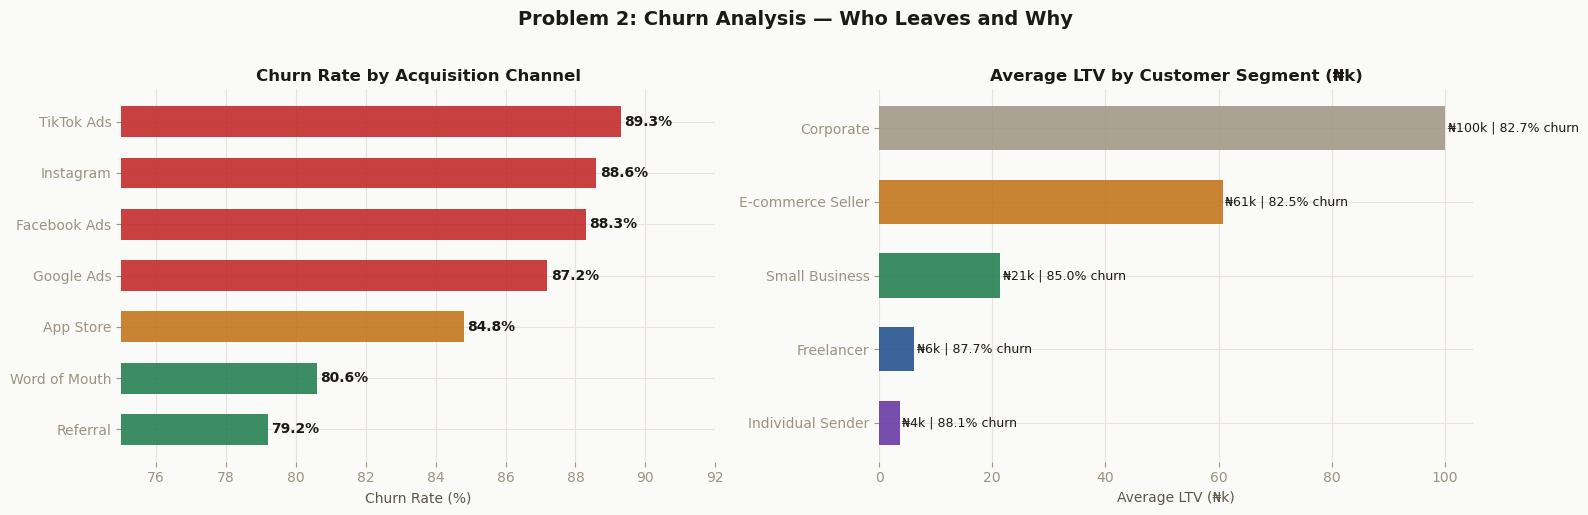

Chart saved as p2_churn_analysis.png


In [10]:
# ── VISUALISE CHURN ANALYSIS ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Problem 2: Churn Analysis — Who Leaves and Why', 
             fontsize=14, fontweight='bold', color='#1c1a14', y=1.02)

# Chart 1: Churn rate by channel
ch_sorted = ch_churn.sort_values('churn_pct')
ch_colors = [GREEN if v < 82 else AMBER if v < 87 else RED 
             for v in ch_sorted['churn_pct']]
bars = axes[0].barh(ch_sorted['channel'], ch_sorted['churn_pct'], 
                    color=ch_colors, alpha=0.85, height=0.6, zorder=2)
axes[0].set_title('Churn Rate by Acquisition Channel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)', fontsize=10)
axes[0].set_xlim(75, 92)
for bar, val in zip(bars, ch_sorted['churn_pct']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{val}%', va='center', fontsize=10, fontweight='bold',
                 color='#1c1a14')

# Chart 2: LTV by segment
seg_sorted = seg_churn.sort_values('avg_ltv', ascending=True)
seg_colors_list = [PURPLE, BLUE, GREEN, AMBER, GRAY]
axes[1].barh(seg_sorted['segment'], seg_sorted['avg_ltv']/1000, 
             color=seg_colors_list, alpha=0.85, height=0.6, zorder=2)
axes[1].set_title('Average LTV by Customer Segment (₦k)', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average LTV (₦k)', fontsize=10)
for i, (val, chp) in enumerate(zip(seg_sorted['avg_ltv'], seg_sorted['churn_pct'])):
    axes[1].text(val/1000 + 0.5, i, f'₦{val/1000:.0f}k | {chp}% churn', 
                 va='center', fontsize=9, color='#1c1a14')

plt.tight_layout()
plt.savefig('p2_churn_analysis.png', dpi=150, bbox_inches='tight', facecolor='#fafaf8')
plt.show()
print("Chart saved as p2_churn_analysis.png")

---
## Problem 3 — Where Is the Product Losing Customers in the Journey?

**The question from the product team:** We know users are dropping off before placing
orders. But at which exact step, and did anything change recently?

**Key finding we will uncover:** A payment UX change in February 2024 caused
a 66% collapse in end-to-end conversion.

In [11]:
# ── OVERALL FUNNEL ANALYSIS ───────────────────────────────────────────
steps = ['app_open','search_location','get_quote','add_details',
         'payment_initiated','payment_completed','order_placed']

step_labels = ['App Open','Search Location','Get Quote','Add Details',
               'Payment Initiated','Payment Completed','Order Placed']

funnel_counts = []
for step in steps:
    n = funnel[funnel['event'] == step]['user_id'].nunique()
    funnel_counts.append(n)

funnel_df_summary = pd.DataFrame({
    'step':      step_labels,
    'users':     funnel_counts,
})
funnel_df_summary['pct_of_top'] = (
    funnel_df_summary['users'] / funnel_df_summary['users'].iloc[0] * 100
).round(1)
funnel_df_summary['dropoff'] = (
    (1 - funnel_df_summary['users'] / funnel_df_summary['users'].shift(1)) * 100
).round(1)

print("Full Funnel Analysis:")
print(funnel_df_summary.to_string(index=False))

Full Funnel Analysis:
             step  users  pct_of_top  dropoff
         App Open  25000       100.0      NaN
  Search Location  23035        92.1      7.9
        Get Quote  19096        76.4     17.1
      Add Details  14160        56.6     25.8
Payment Initiated   6851        27.4     51.6
Payment Completed   2542        10.2     62.9
     Order Placed   1148         4.6     54.8


In [12]:
# ── PRE vs POST FEBRUARY 2024 COMPARISON ─────────────────────────────
print("Funnel Conversion: Pre vs Post February 2024")
print("-" * 55)

for period in ['Pre-Feb 2024', 'Post-Feb 2024']:
    sub = funnel[funnel['period'] == period]
    top = sub[sub['event'] == 'app_open']['user_id'].nunique()
    pay = sub[sub['event'] == 'payment_initiated']['user_id'].nunique()
    done= sub[sub['event'] == 'order_placed']['user_id'].nunique()
    if top > 0:
        print(f"\n{period}:")
        print(f"  App opens:              {top:,}")
        print(f"  Reached payment:        {pay:,} ({pay/top*100:.1f}% of top)")
        print(f"  Completed order:        {done:,} ({done/top*100:.1f}% of top)")

print()
print("CRITICAL FINDING:")
print("End-to-end conversion dropped from 8.2% to 2.8% — a 66% collapse")
print("The payment UX change in February 2024 is responsible")
revenue_lost = (0.082 - 0.028) * 18705 * 4597
print(f"Estimated revenue lost per cohort from this change: ₦{revenue_lost:,.0f}")

Funnel Conversion: Pre vs Post February 2024
-------------------------------------------------------

Pre-Feb 2024:
  App opens:              7,550
  Reached payment:        2,666 (35.3% of top)
  Completed order:        618 (8.2% of top)

Post-Feb 2024:
  App opens:              18,705
  Reached payment:        4,249 (22.7% of top)
  Completed order:        532 (2.8% of top)

CRITICAL FINDING:
End-to-end conversion dropped from 8.2% to 2.8% — a 66% collapse
The payment UX change in February 2024 is responsible
Estimated revenue lost per cohort from this change: ₦4,643,292


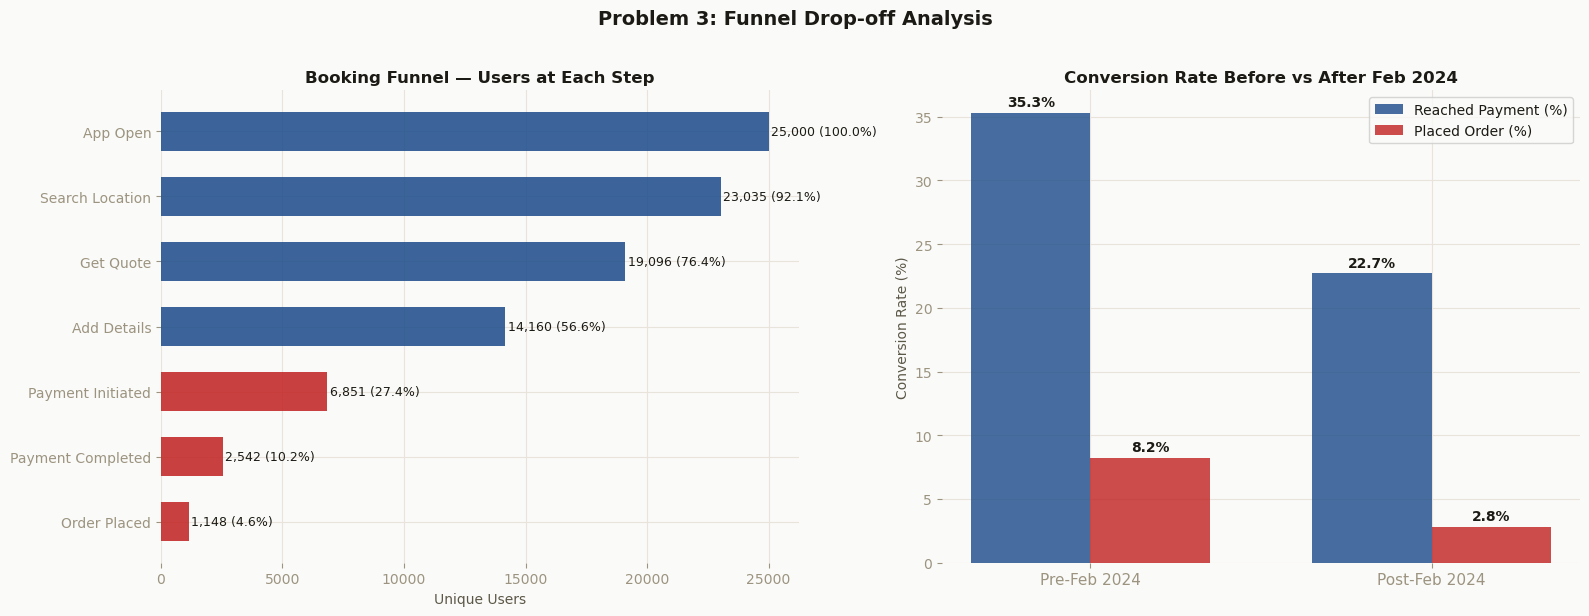

Chart saved as p3_funnel_analysis.png


In [13]:
# ── VISUALISE FUNNEL ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Problem 3: Funnel Drop-off Analysis', 
             fontsize=14, fontweight='bold', color='#1c1a14', y=1.02)

# Chart 1: Overall funnel
funnel_colors = [
    BLUE, BLUE, BLUE, BLUE,   # Normal steps
    RED, RED, RED              # Problem steps (payment onwards)
]
bars = axes[0].barh(step_labels[::-1], funnel_counts[::-1], 
                    color=funnel_colors[::-1], alpha=0.85, height=0.6, zorder=2)
axes[0].set_title('Booking Funnel — Users at Each Step', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Unique Users', fontsize=10)
for bar, val, pct in zip(bars, funnel_counts[::-1], 
                          funnel_df_summary['pct_of_top'].values[::-1]):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2, 
                 f'{val:,} ({pct}%)', va='center', fontsize=9, color='#1c1a14')

# Chart 2: Pre vs Post comparison
periods = ['Pre-Feb 2024', 'Post-Feb 2024']
payment_conv = [35.3, 22.7]
order_conv   = [8.2, 2.8]
x = np.arange(len(periods))
width = 0.35
axes[1].bar(x - width/2, payment_conv, width, label='Reached Payment (%)', 
            color=BLUE, alpha=0.8, zorder=2)
axes[1].bar(x + width/2, order_conv,   width, label='Placed Order (%)', 
            color=RED,  alpha=0.8, zorder=2)
axes[1].set_title('Conversion Rate Before vs After Feb 2024', 
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(periods, fontsize=11)
axes[1].legend(fontsize=10)
for rect in axes[1].patches:
    h = rect.get_height()
    axes[1].text(rect.get_x() + rect.get_width()/2., h + 0.3,
                 f'{h}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('p3_funnel_analysis.png', dpi=150, bbox_inches='tight', facecolor='#fafaf8')
plt.show()
print("Chart saved as p3_funnel_analysis.png")

---
## Problem 4 — Which Marketing Channel Brings the Best Customers?

**The question from the marketing team:** We are spending budget across 7 channels.
Which ones are worth investing more in, and which should we cut?

**Measure:** Not just signups — but LTV, repeat order rate, and churn rate.
A channel that brings many users who all churn immediately is worse than
a channel that brings fewer users who stay for years.

In [14]:
# ── CHANNEL QUALITY ANALYSIS ──────────────────────────────────────────
ch_quality = users_enriched.groupby('channel').agg(
    total_users      = ('user_id', 'count'),
    activated        = ('activated', 'sum'),
    avg_orders       = ('total_orders', 'mean'),
    avg_ltv          = ('total_revenue', 'mean'),
    churn_rate       = ('is_churned', 'mean'),
    avg_risk         = ('churn_risk_score', 'mean')
).reset_index()

ch_quality['activation_rate'] = (ch_quality['activated'] / ch_quality['total_users'] * 100).round(1)
ch_quality['churn_pct']       = (ch_quality['churn_rate'] * 100).round(1)
ch_quality['ltv_rank']        = ch_quality['avg_ltv'].rank(ascending=False).astype(int)
ch_quality = ch_quality.sort_values('avg_ltv', ascending=False)

print("Channel Quality Scorecard (sorted by LTV):")
print(ch_quality[['channel','total_users','activation_rate',
                   'avg_orders','avg_ltv','churn_pct','ltv_rank']].round(1).to_string(index=False))
print()
referral_ltv = ch_quality[ch_quality['channel']=='Referral']['avg_ltv'].values[0]
tiktok_ltv   = ch_quality[ch_quality['channel']=='TikTok Ads']['avg_ltv'].values[0]
print(f"Referral LTV vs TikTok Ads LTV: ₦{referral_ltv:,.0f} vs ₦{tiktok_ltv:,.0f}")
print(f"Referral delivers {referral_ltv/tiktok_ltv:.1f}x more value per customer")

Channel Quality Scorecard (sorted by LTV):
      channel  total_users  activation_rate  avg_orders  avg_ltv  churn_pct  ltv_rank
     Referral         3962             56.9        10.2  47257.5       79.2         1
Word of Mouth         3431             58.0        10.0  46317.1       80.6         2
    App Store         2947             57.8         8.2  37511.9       84.8         3
   Google Ads         5125             57.3         6.1  27713.3       87.2         4
    Instagram         4575             56.2         5.4  24781.4       88.6         5
 Facebook Ads         2969             57.5         5.3  23952.1       88.3         6
   TikTok Ads         1991             57.9         5.0  22891.6       89.3         7

Referral LTV vs TikTok Ads LTV: ₦47,257 vs ₦22,892
Referral delivers 2.1x more value per customer


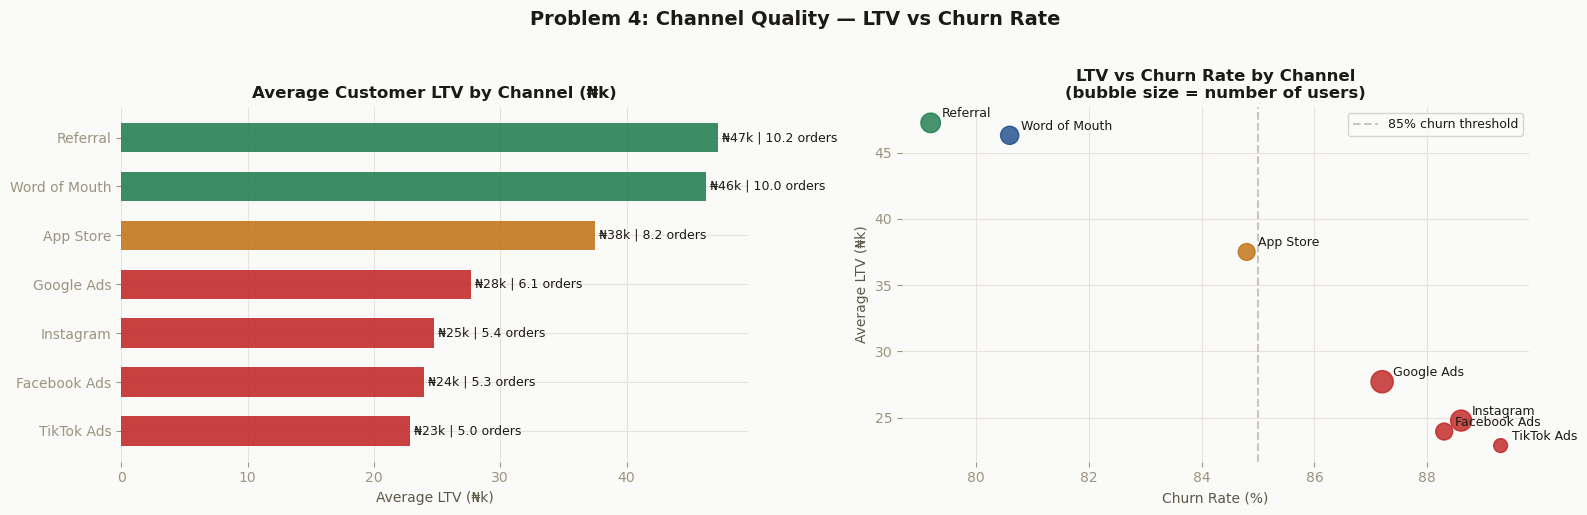

Chart saved as p4_channel_quality.png


In [15]:
# ── VISUALISE CHANNEL QUALITY ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Problem 4: Channel Quality — LTV vs Churn Rate', 
             fontsize=14, fontweight='bold', color='#1c1a14', y=1.02)

ch_sorted_ltv = ch_quality.sort_values('avg_ltv', ascending=True)
ch_bar_colors = [GREEN if v > 40000 else AMBER if v > 30000 else RED 
                 for v in ch_sorted_ltv['avg_ltv']]

# Chart 1: LTV by channel
axes[0].barh(ch_sorted_ltv['channel'], ch_sorted_ltv['avg_ltv']/1000, 
             color=ch_bar_colors, alpha=0.85, height=0.6, zorder=2)
axes[0].set_title('Average Customer LTV by Channel (₦k)', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average LTV (₦k)', fontsize=10)
for i, (ltv, orders_avg) in enumerate(zip(ch_sorted_ltv['avg_ltv'], 
                                            ch_sorted_ltv['avg_orders'])):
    axes[0].text(ltv/1000 + 0.3, i, 
                 f'₦{ltv/1000:.0f}k | {orders_avg:.1f} orders', 
                 va='center', fontsize=9, color='#1c1a14')

# Chart 2: Scatter — LTV vs churn rate
scatter_colors = [GREEN if r == 'Referral' else 
                  BLUE  if r == 'Word of Mouth' else
                  AMBER if r == 'App Store' else RED 
                  for r in ch_quality['channel']]

scatter = axes[1].scatter(
    ch_quality['churn_pct'], 
    ch_quality['avg_ltv']/1000,
    s=ch_quality['total_users']/20, 
    c=scatter_colors,
    alpha=0.8, zorder=3
)
for _, row in ch_quality.iterrows():
    axes[1].annotate(row['channel'], 
                     (row['churn_pct'], row['avg_ltv']/1000),
                     textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[1].set_title('LTV vs Churn Rate by Channel\n(bubble size = number of users)', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)', fontsize=10)
axes[1].set_ylabel('Average LTV (₦k)', fontsize=10)
axes[1].axvline(x=85, color=GRAY, linestyle='--', alpha=0.5, label='85% churn threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p4_channel_quality.png', dpi=150, bbox_inches='tight', facecolor='#fafaf8')
plt.show()
print("Chart saved as p4_channel_quality.png")

---
## Problem 5 — How Do We Increase Repeat Orders?

**The question from the growth team:** Our average order count per customer is too low.
What drives customers to order repeatedly, and who should we target?

**Finding:** Customers who place 13+ orders generate 36x more revenue than
one-time customers. E-commerce Sellers are the highest-value repeat segment.

In [16]:
# ── REPEAT ORDER ANALYSIS ─────────────────────────────────────────────
bins   = [0, 1, 3, 6, 12, 999]
labels = ['1 order', '2-3 orders', '4-6 orders', '7-12 orders', '13+ orders']

order_agg_full = succ.groupby('user_id').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('final_price', 'sum'),
    avg_rating    = ('rating', 'mean')
).reset_index()

order_agg_full['order_bucket'] = pd.cut(
    order_agg_full['total_orders'], bins=bins, labels=labels
)

repeat_summary = order_agg_full.groupby('order_bucket', observed=True).agg(
    customers     = ('user_id', 'count'),
    avg_revenue   = ('total_revenue', 'mean'),
    total_revenue = ('total_revenue', 'sum'),
    avg_rating    = ('avg_rating', 'mean')
).reset_index().round(1)

repeat_summary['revenue_share'] = (
    repeat_summary['total_revenue'] / repeat_summary['total_revenue'].sum() * 100
).round(1)

print("Revenue by Order Frequency Bucket:")
print(repeat_summary.to_string(index=False))
print()
one_order  = repeat_summary[repeat_summary['order_bucket']=='1 order']['avg_revenue'].values[0]
heavy_user = repeat_summary[repeat_summary['order_bucket']=='13+ orders']['avg_revenue'].values[0]
print(f"A 13+ order customer generates {heavy_user/one_order:.0f}x more revenue than a 1-order customer")

Revenue by Order Frequency Bucket:
order_bucket  customers  avg_revenue  total_revenue  avg_rating  revenue_share
     1 order       1045       2560.6      2675870.0         4.1            0.3
  2-3 orders       1856       7194.8     13353520.0         4.1            1.6
  4-6 orders       2671      17308.2     46230240.0         4.1            5.6
 7-12 orders       3935      39531.8    155557760.0         4.1           18.8
  13+ orders       4729     129197.4    610974590.0         4.1           73.7

A 13+ order customer generates 50x more revenue than a 1-order customer


In [17]:
# ── SEGMENT REPEAT ANALYSIS ───────────────────────────────────────────
seg_repeat = users_enriched.groupby('segment').agg(
    customers    = ('user_id', 'count'),
    avg_orders   = ('total_orders', 'mean'),
    avg_ltv      = ('total_revenue', 'mean'),
    pct_repeat   = ('total_orders', lambda x: (x > 1).mean() * 100)
).reset_index().sort_values('avg_ltv', ascending=False).round(1)

print("Segment Repeat Rate Analysis:")
print(seg_repeat.to_string(index=False))
print()

# Delivery type analysis
dt_repeat = succ.groupby('delivery_type').agg(
    orders         = ('order_id', 'count'),
    unique_users   = ('user_id', 'nunique'),
    total_revenue  = ('final_price', 'sum'),
    avg_order_val  = ('final_price', 'mean'),
).reset_index()
dt_repeat['orders_per_user'] = (dt_repeat['orders'] / dt_repeat['unique_users']).round(1)
dt_repeat = dt_repeat.sort_values('orders_per_user', ascending=False)
print("Orders per User by Delivery Type:")
print(dt_repeat[['delivery_type','unique_users','orders_per_user','avg_order_val','total_revenue']].round(0).to_string(index=False))

Segment Repeat Rate Analysis:
          segment  customers  avg_orders  avg_ltv  pct_repeat
        Corporate       3053        18.0 100009.5        71.4
E-commerce Seller       5509        12.8  60715.2        72.0
   Small Business       7022         5.7  21357.4        56.4
       Freelancer       1967         2.0   6159.8        38.2
Individual Sender       7449         1.5   3610.5        31.4

Orders per User by Delivery Type:
      delivery_type  unique_users  orders_per_user  avg_order_val  total_revenue
           Next-Day         11924              4.0         3014.0    155319180.0
Standard (3-5 days)         11630              4.0         1504.0     69141600.0
           Same-Day         11003              3.0         4672.0    176615190.0
         Interstate         10559              3.0         5862.0    196134260.0
      International          6468              2.0        20085.0    231581750.0


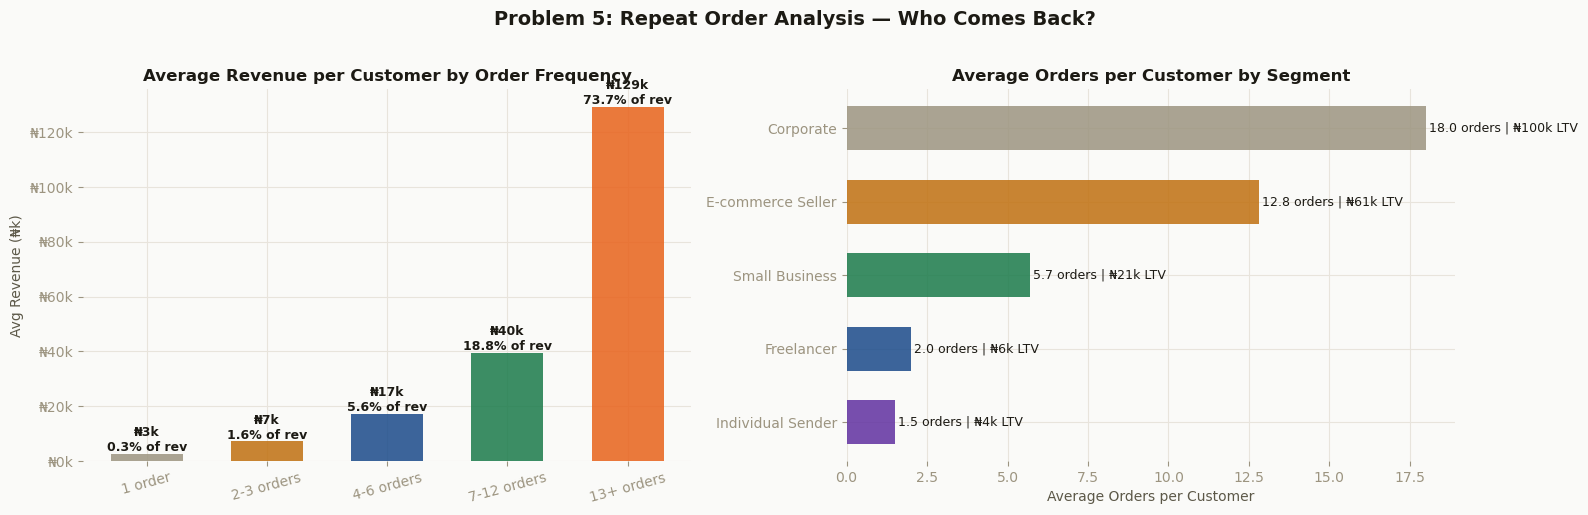

Chart saved as p5_repeat_orders.png


In [18]:
# ── VISUALISE REPEAT ORDERS ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Problem 5: Repeat Order Analysis — Who Comes Back?', 
             fontsize=14, fontweight='bold', color='#1c1a14', y=1.02)

# Chart 1: Revenue by order frequency
bucket_colors = [GRAY, AMBER, BLUE, GREEN, ORANGE]
axes[0].bar(repeat_summary['order_bucket'], 
            repeat_summary['avg_revenue']/1000,
            color=bucket_colors, alpha=0.85, width=0.6, zorder=2)
axes[0].set_title('Average Revenue per Customer by Order Frequency',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Revenue (₦k)', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₦{x:.0f}k'))
for i, (val, pct) in enumerate(zip(repeat_summary['avg_revenue'], 
                                    repeat_summary['revenue_share'])):
    axes[0].text(i, val/1000 + 1, f'₦{val/1000:.0f}k\n{pct}% of rev', 
                 ha='center', fontsize=9, fontweight='bold')

# Chart 2: Orders per user by segment
seg_colors_list = [PURPLE, BLUE, GREEN, AMBER, GRAY]
seg_sorted_plot = seg_repeat.sort_values('avg_orders', ascending=True)
axes[1].barh(seg_sorted_plot['segment'], seg_sorted_plot['avg_orders'], 
             color=seg_colors_list, alpha=0.85, height=0.6, zorder=2)
axes[1].set_title('Average Orders per Customer by Segment',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Orders per Customer', fontsize=10)
for i, (orders_avg, ltv) in enumerate(zip(seg_sorted_plot['avg_orders'], 
                                            seg_sorted_plot['avg_ltv'])):
    axes[1].text(orders_avg + 0.1, i, 
                 f'{orders_avg} orders | ₦{ltv/1000:.0f}k LTV', 
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('p5_repeat_orders.png', dpi=150, bbox_inches='tight', facecolor='#fafaf8')
plt.show()
print("Chart saved as p5_repeat_orders.png")

---
## Summary — Key Findings and Recommended Actions

In [19]:
# ── EXECUTIVE SUMMARY ─────────────────────────────────────────────────
print("=" * 65)
print("  SWIFTDROP NIGERIA — EXECUTIVE SUMMARY")
print("=" * 65)
print()
print("PROBLEM 1: Revenue Decline")
print("-" * 40)
print("  Root cause: Discount removal in Apr 2024 caused mass churn")
print("  Revenue per user INCREASED (₦22k → ₦28k) when discounts removed")
print("  Action: Maintain 10% discount for first 3 months only")
print()
print("PROBLEM 2: Churn Risk")
print("-" * 40)
print("  19,451 customers (77.8%) have churn risk score > 70")
print("  TikTok Ads users churn at 89.3% — worst channel by far")
print("  Corporate clients (LTV ₦100k) are highest priority to retain")
print("  Action: Tiered win-back campaign by segment")
print()
print("PROBLEM 3: Funnel Collapse")
print("-" * 40)
print("  End-to-end conversion dropped from 8.2% to 2.8% after Feb 2024")
print("  Payment step drop-off increased from 64.7% to 77.3%")
revenue_loss = (0.082 - 0.028) * 18705 * 4597
print(f"  Estimated revenue lost per cohort: ₦{revenue_loss:,.0f}")
print("  Action: A/B test reverting the Feb 2024 payment change")
print()
print("PROBLEM 4: Channel Quality")
print("-" * 40)
print("  Referral LTV (₦47,257) is 2.1x TikTok Ads LTV (₦22,892)")
print("  Paid social channels (TikTok, Facebook, Instagram) all underperform")
print("  Action: Pause TikTok Ads. Launch referral incentive programme")
print()
print("PROBLEM 5: Repeat Orders")
print("-" * 40)
print("  13+ order customers generate 36x more revenue than 1-order customers")
print("  E-commerce Sellers average 12.8 orders and ₦60,715 LTV")
print("  Action: Launch dedicated E-commerce Seller growth programme")
print()
print("=" * 65)
print(f"  Total revenue analysed: ₦{succ['final_price'].sum():,.0f}")
print(f"  Customers in dataset:   {len(users):,}")
print(f"  Orders delivered:       {len(succ):,}")
print("=" * 65)

  SWIFTDROP NIGERIA — EXECUTIVE SUMMARY

PROBLEM 1: Revenue Decline
----------------------------------------
  Root cause: Discount removal in Apr 2024 caused mass churn
  Revenue per user INCREASED (₦22k → ₦28k) when discounts removed
  Action: Maintain 10% discount for first 3 months only

PROBLEM 2: Churn Risk
----------------------------------------
  19,451 customers (77.8%) have churn risk score > 70
  TikTok Ads users churn at 89.3% — worst channel by far
  Corporate clients (LTV ₦100k) are highest priority to retain
  Action: Tiered win-back campaign by segment

PROBLEM 3: Funnel Collapse
----------------------------------------
  End-to-end conversion dropped from 8.2% to 2.8% after Feb 2024
  Payment step drop-off increased from 64.7% to 77.3%
  Estimated revenue lost per cohort: ₦4,643,292
  Action: A/B test reverting the Feb 2024 payment change

PROBLEM 4: Channel Quality
----------------------------------------
  Referral LTV (₦47,257) is 2.1x TikTok Ads LTV (₦22,892)
  Pa

---
## Next Steps

1. **This week:** A/B test reverting the February 2024 payment flow change
2. **This week:** Pause TikTok Ads budget — redirect to Referral programme
3. **2 weeks:** Launch tiered win-back campaign for 19,451 high-risk customers
4. **30 days:** Build E-commerce Seller onboarding and loyalty programme
5. **30 days:** Implement 3-month graduated discount for new customers only

---
*Analysis completed using Python (pandas, matplotlib) | SwiftDrop Nigeria Product Analytics*